# ЛР 1.2: Множественная регрессия

# **Теоретическая часть**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split


x = pd.read_csv("https://github.com/koroteevmv/ML_course/raw/main/ML1.2%20multivariate/data/0_x.csv", header=None)
y = pd.read_csv("https://github.com/koroteevmv/ML_course/raw/main/ML1.2%20multivariate/data/0_y.csv", header=None)

print(x.head())
print(y.head())
print()
print(x.shape)
print(y.shape)


          0         1         2         3         4
0  0.071841  0.855352 -0.305597  0.028253  1.826895
1  0.139521 -0.423507  0.461059 -0.447400 -0.034988
2  1.626311 -0.257622 -0.697520  1.413219  1.086292
3 -1.183233 -0.826343  0.073047 -0.639690 -0.503273
4 -0.783365 -0.861232  0.951448 -0.117306  0.680597
            0
0   63.320498
1  -23.426394
2   11.982771
3 -102.883304
4  -49.373475

(387, 5)
(387, 1)


## Создание объекта линейной регрессии и обучение

In [2]:
binary = LinearRegression()

binary.fit(x[[1]], y)

print(binary.coef_)

[[95.52010745]]


## Парная регресия на полигоне значений

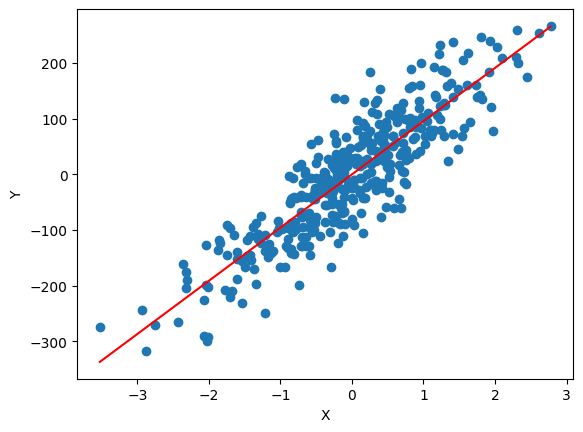

In [3]:
binary.predict(x[[1]])

plt.scatter(x[1], y)
plt.xlabel("X")
plt.ylabel("Y")

xx = np.linspace(x[1].min(), x[1].max(), 100).reshape((-1, 1))
plt.plot(xx, binary.predict(xx), c='r')

## Оценка качества регрессии

In [4]:
Y = binary.predict(x[[1]])

print("Коэффициент детерминации модели парной регрессии (1 столбец X с Y) = ", round(sklearn.metrics.r2_score(y, Y), 5))

Коэффициент детерминации модели парной регрессии (1 столбец X с Y) =  0.76997


## Множественная регрессия

In [5]:
multiple = LinearRegression()
multiple.fit(x, y)
print("Коэффициент детерминации модели множественной регрессии (1 столбец X с Y) = ", round(multiple.score(x, y), 5))

Коэффициент детерминации модели множественной регрессии (1 столбец X с Y) =  0.99222


### График сравнения эмпирических и теоретических измерений по модели множественной регрессии

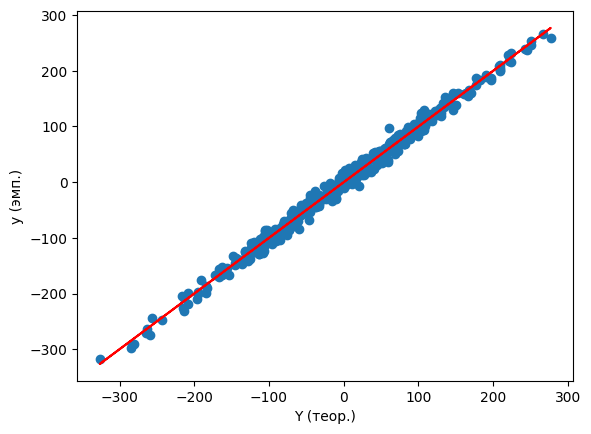

In [6]:
yy = multiple.predict(x)
plt.scatter(yy, y)
plt.xlabel("Y (теор.)")
plt.ylabel("y (эмп.)")
plt.plot(yy, yy, c='r')

# =======================================================================================

# **Самостоятельные задания**

## 1. Парные регрессии от каждого атрибута (x1 - x5)

Модель с атрибутом x[1]:

Коэффициент при параметре X - [22.78111342]
Коэффициент детерминации парной модели регрессии = -0.40945




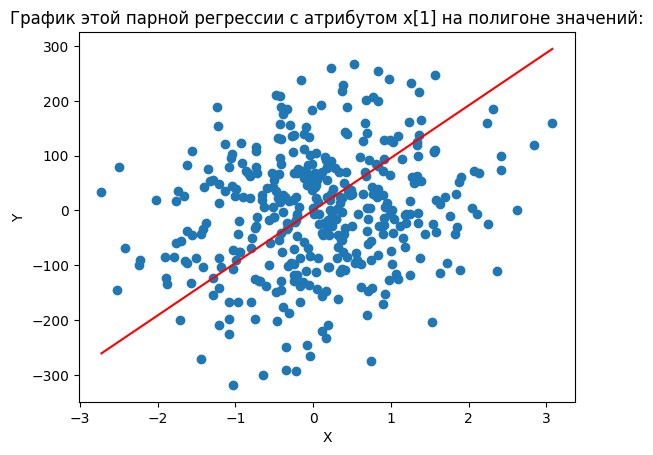





Модель с атрибутом x[2]:

Коэффициент при параметре X - [95.52010745]
Коэффициент детерминации парной модели регрессии = 0.76997




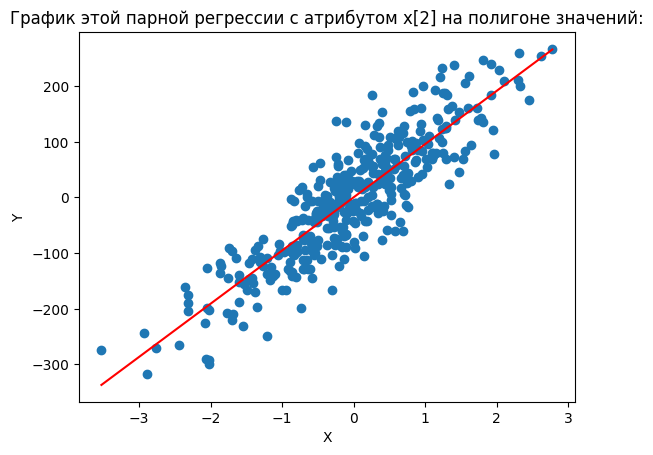





Модель с атрибутом x[3]:

Коэффициент при параметре X - [46.94897635]
Коэффициент детерминации парной модели регрессии = -0.01702




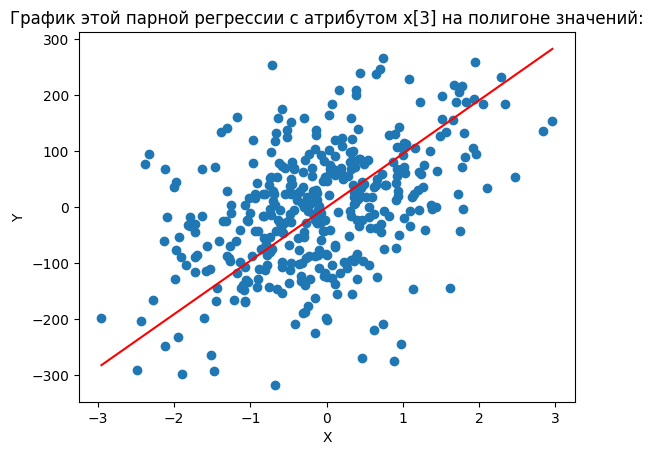





Модель с атрибутом x[4]:

Коэффициент при параметре X - [23.99882407]
Коэффициент детерминации парной модели регрессии = -0.37851




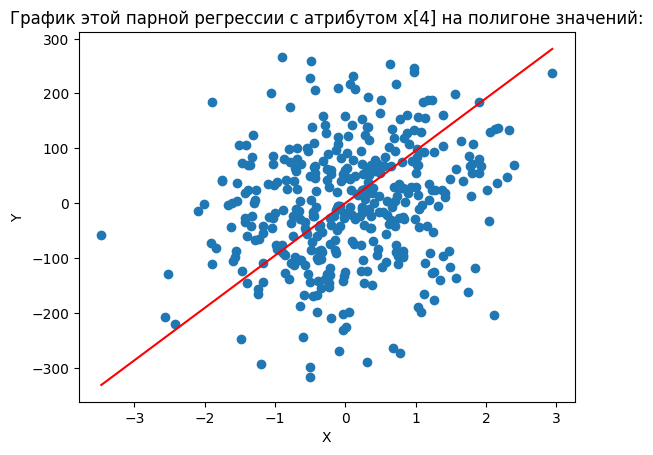





Модель с атрибутом x[5]:

Коэффициент при параметре X - [1.49082042]
Коэффициент детерминации парной модели регрессии = -0.6894




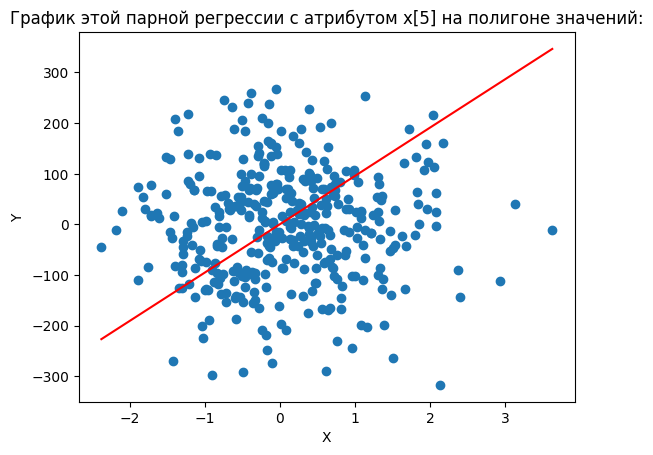

In [7]:
for i in range(len(x.head()[1])):
    binmodel = LinearRegression()
    binmodel.fit(x[[i]], y)

    Y = binary.predict(x[[i]])

    print(f"Модель с атрибутом x[{i+1}]:\n")
    print(f"Коэффициент при параметре X - {binmodel.coef_[0]}")
    print(f"Коэффициент детерминации парной модели регрессии = {round(sklearn.metrics.r2_score(y, Y), 5)}\n\n")

    plt.scatter(x[i], y)
    plt.xlabel("X")
    plt.ylabel("Y")

    xx = np.linspace(x[i].min(), x[i].max(), 100).reshape((-1, 1))
    plt.plot(xx, binary.predict(xx), c='r')
    plt.title(f"График этой парной регрессии c атрибутом x[{i + 1}] на полигоне значений:")
    plt.show()
    print("\n\n============================================================================\n\n")

## 2. Модификация кода из прошлой работы

### Проверка улучшенной автообучаемой модели с рисованием графиков

In [8]:
class Model:
    """Модель множественной линейной регрессии"""

    def __init__(self):
        self.b = None

    def predict(self, X):
        X = np.array(X)
        X_with_ones = np.hstack([np.ones((X.shape[0], 1)), X]) # Массив склееный hstack состоящий из 1 столбца из 1 и далее из X
        return X_with_ones @ self.b

    def error(self, X, Y):
        Y_pred = self.predict(X)
        Y = np.array(Y).flatten() # Переделываем массив [m, 1] в одномерный [m]
        return np.sum((Y_pred - Y) ** 2) / (2 * len(Y))

    def fit(self, X, Y, alpha=0.01, max_steps=1000):
        X = np.array(X)
        Y = np.array(Y).flatten()
        m = len(Y) # Кол-во строк
        n = X.shape[1] # Кол-во столбцов

        X_with_ones = np.hstack([np.ones((m, 1)), X])

        self.b = np.zeros(n + 1)

        errors = []

        for step in range(max_steps):
            Y_pred = X_with_ones @ self.b

            gradients = (1/m) * (X_with_ones.T @ (Y_pred - Y))

            self.b -= alpha * gradients

            errors.append(self.error(X, Y))

        return errors

    def score(self, X, Y):
        Y_pred = self.predict(X)
        Y = np.array(Y).flatten()
        rss = np.sum((Y - Y_pred) ** 2)
        tss = np.sum((Y - np.mean(Y)) ** 2)

        return 1 - (rss / tss)

## Проверим работоспособность

In [14]:
model = Model()

errors = model.fit(x, y, alpha=0.01, max_steps=1000)

print(f"\nКоэффициенты модели:")
print(f"b0 (свободный член) = {model.b[0]:.4f}")
for i in range(1, len(model.b)):
    print(f"b{i} (признак x{i-1}) = {model.b[i]:.4f}")

print(f"\nФинальная ошибка: {model.error(x, y):.4f}")
print(f"R² score: {model.score(x, y):.4f}")



Коэффициенты модели:
b0 (свободный член) = 0.5645
b1 (признак x0) = 15.7986
b2 (признак x1) = 93.2079
b3 (признак x2) = 37.1969
b4 (признак x3) = 31.1854
b5 (признак x4) = -0.2350

Финальная ошибка: 46.7462
R² score: 0.9922


## График регрессии на полигоне и График ошибки

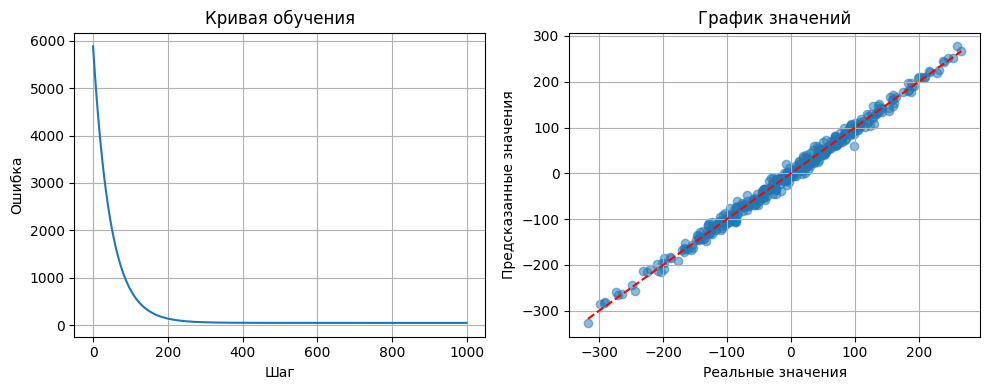

In [15]:
plt.figure(figsize=(10, 4))

# График ошибки
plt.subplot(1, 2, 1)
plt.plot(errors)
plt.xlabel('Шаг')
plt.ylabel('Ошибка')
plt.title('Кривая обучения')
plt.grid(True)

# График регрессии
plt.subplot(1, 2, 2)
y_pred = model.predict(x)
plt.scatter(y, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Реальные значения')
plt.ylabel('Предсказанные значения')
plt.title(f'График значений')
plt.grid(True)

plt.tight_layout()
plt.show()

## 3. Полиномиальная регрессия 2, 3 и 10 порядков


Признак 0:
  Полином степени 2: R2 = 0.0437


C:\Users\Bush\AppData\Local\Temp\ipykernel_21116\3681531593.py:30: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, new_row], ignore_index=True)


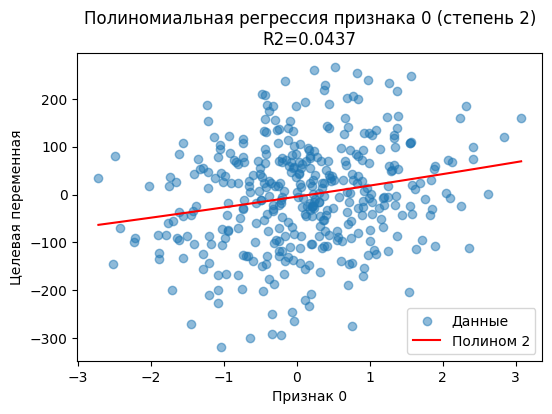

  Полином степени 3: R2 = 0.0438


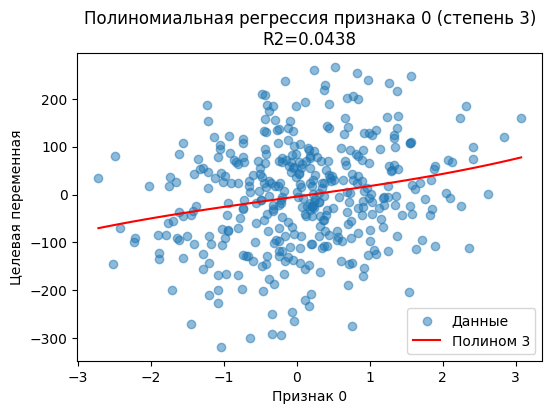

  Полином степени 10: R2 = 0.0504


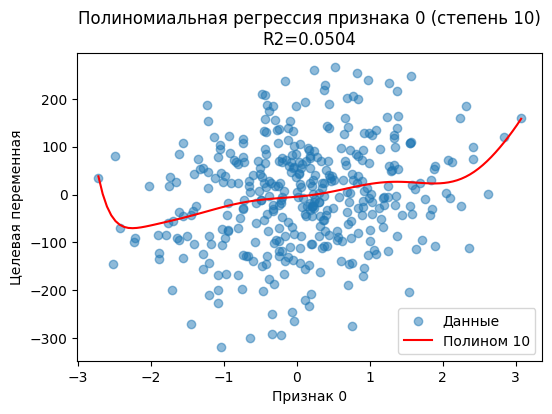




Признак 1:
  Полином степени 2: R2 = 0.7700


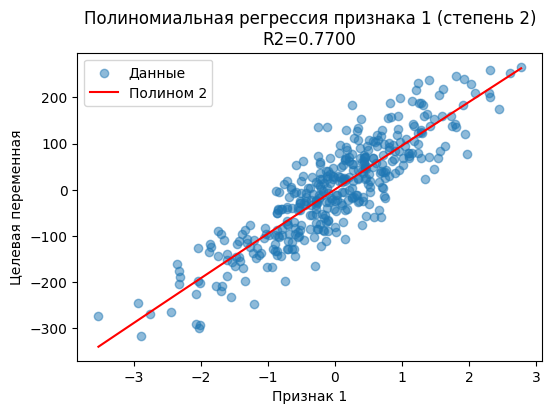

  Полином степени 3: R2 = 0.7711


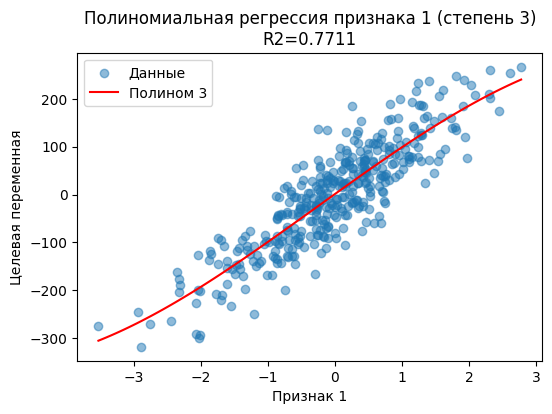

  Полином степени 10: R2 = 0.7727


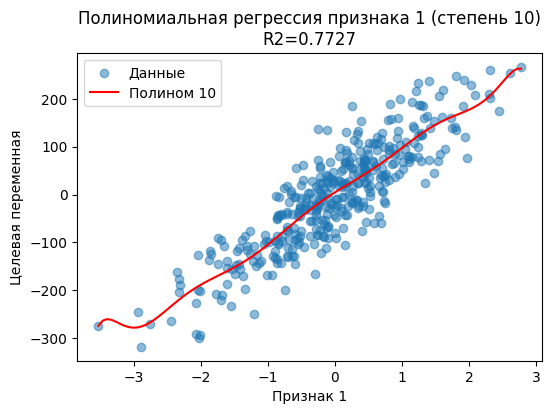




Признак 2:
  Полином степени 2: R2 = 0.1900


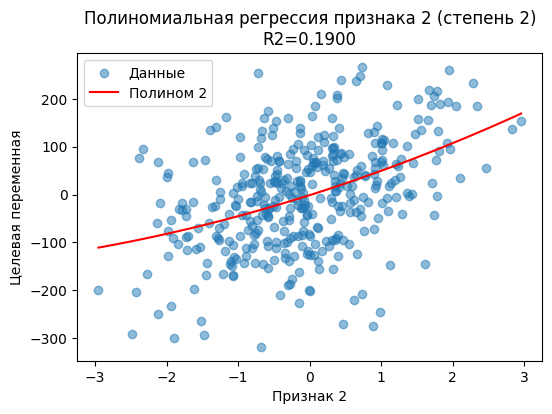

  Полином степени 3: R2 = 0.1928


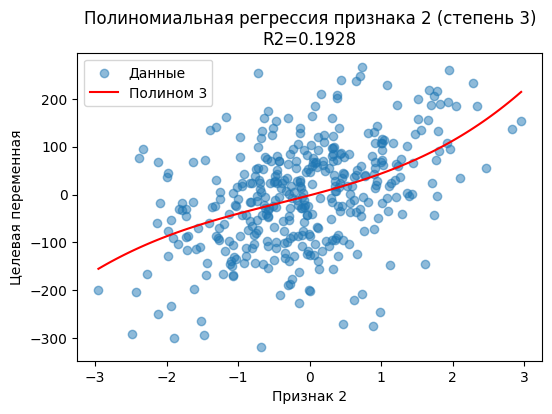

  Полином степени 10: R2 = 0.2044


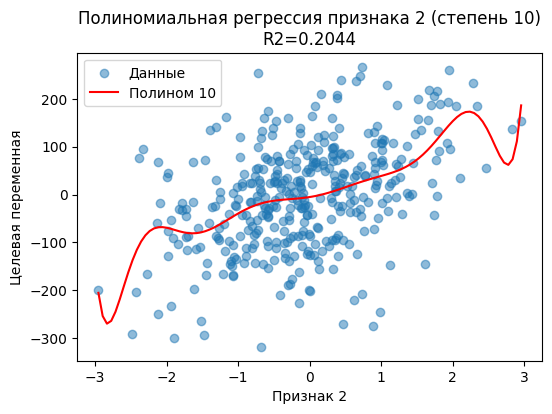




Признак 3:
  Полином степени 2: R2 = 0.0479


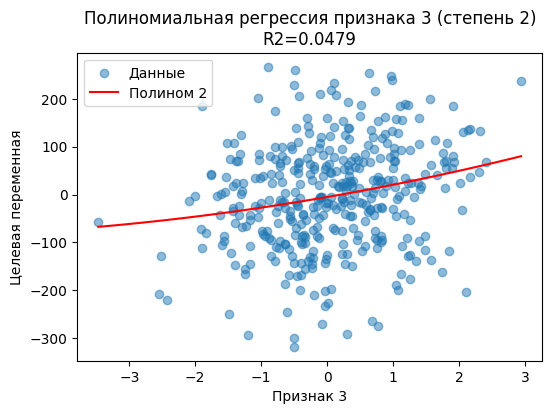

  Полином степени 3: R2 = 0.0503


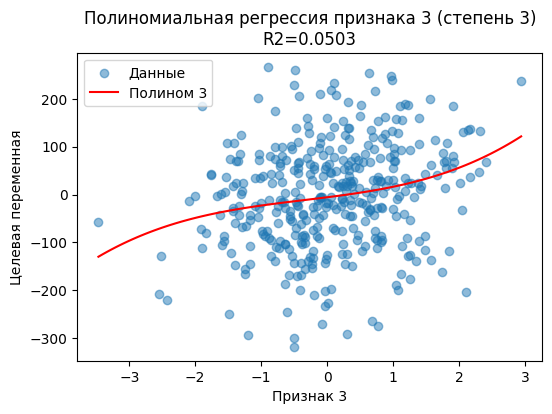

  Полином степени 10: R2 = 0.0727


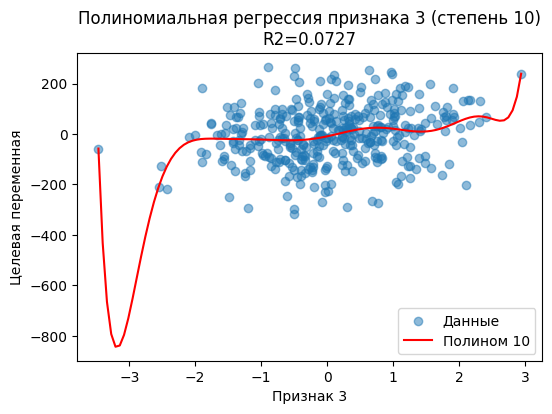




Признак 4:
  Полином степени 2: R2 = 0.0010


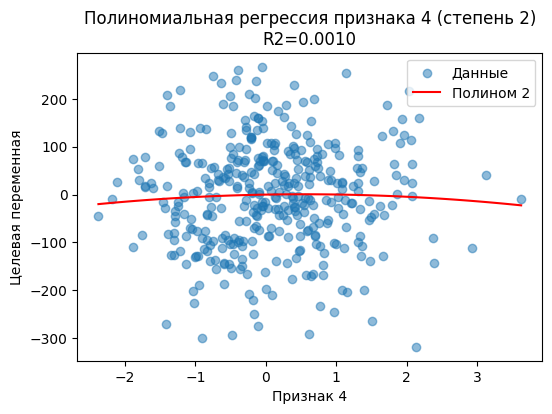

  Полином степени 3: R2 = 0.0011


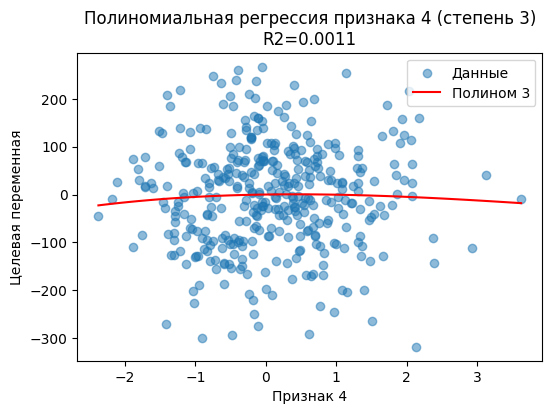

  Полином степени 10: R2 = 0.0451


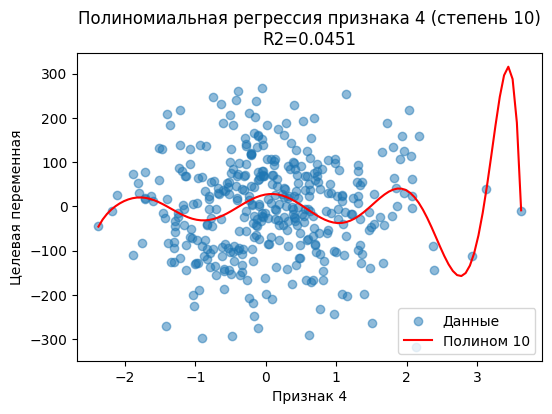




Таблица значений R2:
Degree         2         3         10
Feature                              
0        0.043672  0.043765  0.050356
1        0.769994  0.771118  0.772677
2        0.190008  0.192802  0.204409
3        0.047943  0.050312  0.072667
4        0.001049  0.001065  0.045053


In [10]:
y = y.values.ravel()  # Превратим в 1D-массив (нужно для sklearn)

degrees = [2, 3, 10]
n_features = x.shape[1]

results = pd.DataFrame(columns=['Feature', 'Degree', 'R2'])

for feature_idx in range(n_features):
    X_feature = x[[feature_idx]].values  # 2D-форма, по одному признаку

    print(f"\nПризнак {feature_idx}:")

    for degree in degrees:
        # Создаем полиномиальные признаки заданной степени
        poly = PolynomialFeatures(degree=degree, include_bias=False)
        X_poly = poly.fit_transform(X_feature)

        # Обучаем линейную регрессию на полиномиальных признаках
        model = LinearRegression()
        model.fit(X_poly, y)

        # Предсказания
        y_pred = model.predict(X_poly)

        # Коэффициент детерминации R2
        r2 = r2_score(y, y_pred)

        # Сохраняем результаты
        new_row = pd.DataFrame([{'Feature': feature_idx, 'Degree': degree, 'R2': r2}])
        results = pd.concat([results, new_row], ignore_index=True)

        print(f"  Полином степени {degree}: R2 = {r2:.4f}")

        # Визуализация
        xx = np.linspace(X_feature.min(), X_feature.max(), 100).reshape(-1, 1)
        xx_poly = poly.transform(xx)
        yy = model.predict(xx_poly)

        plt.figure(figsize=(6,4))
        plt.scatter(X_feature, y, alpha=0.5, label='Данные')
        plt.plot(xx, yy, 'r-', label=f'Полином {degree}')
        plt.title(f'Полиномиальная регрессия признака {feature_idx} (степень {degree})\nR2={r2:.4f}')
        plt.xlabel(f'Признак {feature_idx}')
        plt.ylabel('Целевая переменная')
        plt.legend()
        plt.show()
    print("\n================================================================================\n")

# Итоговая таблица R2
print("\nТаблица значений R2:")
print(results.pivot(index='Feature', columns='Degree', values='R2'))

## 4. Сводная таблица показателей точности

In [11]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

degrees = [2, 3, 10]
n_features = x.shape[1]

results_list = []

for feature_idx in range(n_features):
    X_train_feature = X_train[[feature_idx]].values
    X_test_feature = X_test[[feature_idx]].values

    for degree in degrees:
        poly = PolynomialFeatures(degree=degree, include_bias=False)
        X_train_poly = poly.fit_transform(X_train_feature)
        X_test_poly = poly.transform(X_test_feature)

        model = LinearRegression()
        model.fit(X_train_poly, y_train)
        y_train_pred = model.predict(X_train_poly)
        y_test_pred = model.predict(X_test_poly)

        r2_train = r2_score(y_train, y_train_pred)
        r2_test = r2_score(y_test, y_test_pred)

        results_list.append({
            'Feature': feature_idx,
            'Degree': degree,
            'R2_train': r2_train,
            'R2_test': r2_test
        })

results = pd.DataFrame(results_list)


# Анализ моделей по переобучению / недообучению
def model_quality(row):
    if row['R2_train'] - row['R2_test'] > 0.1:
        return 'Переобучение'
    elif row['R2_train'] < 0.5 and row['R2_test'] < 0.5:
        return 'Недообучение'
    else:
        return 'Хорошее обучение'

results['Quality'] = results.apply(model_quality, axis=1)

print("\nАнализ качества моделей:\n")
print(results)


Анализ качества моделей:

    Feature  Degree  R2_train   R2_test           Quality
0         0       2  0.040788  0.043900      Недообучение
1         0       3  0.041156  0.042963      Недообучение
2         0      10  0.055808  0.006346      Недообучение
3         1       2  0.719808  0.846372  Хорошее обучение
4         1       3  0.721794  0.844576  Хорошее обучение
5         1      10  0.725336  0.526826      Переобучение
6         2       2  0.221122  0.139721      Недообучение
7         2       3  0.221717  0.143370      Недообучение
8         2      10  0.231218  0.145869      Недообучение
9         3       2  0.080961 -0.009448      Недообучение
10        3       3  0.083619 -0.006457      Недообучение
11        3      10  0.129061 -0.052636      Переобучение
12        4       2  0.000450 -0.000232      Недообучение
13        4       3  0.000950 -0.002723      Недообучение
14        4      10  0.078164 -0.089177      Переобучение


## 5. Другие метрики качества модели

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y, y_pred) # Средняя абсолютная ошибка
mse = mean_squared_error(y, y_pred)  # Средняя квадратическая ошибка
rmse = np.sqrt(mse) # Корень из средней квадратической ошибки

print(f"Средняя абсолютная ошибка: {round(mae, 5)}")
print(f"Средняя квадратическая ошибка: {round(mse, 5)}")
print(f"Корень из средней квадратической ошибки: {round(rmse, 5)}")

Средняя абсолютная ошибка: 84.796
Средняя квадратическая ошибка: 11475.31494
Корень из средней квадратической ошибки: 107.1229


## 6. Время обучения

In [13]:
import time


y = y.ravel()

degrees = [2, 3, 10]
n_features = x.shape[1]

results = pd.DataFrame(columns=['Feature', 'Degree', 'R2', 'MAE', 'MSE', 'RMSE', 'Time'])

for feature_idx in range(n_features):
    X_feature = x[[feature_idx]].values  # 2D-форма

    for degree in degrees:
        poly = PolynomialFeatures(degree=degree, include_bias=False)
        X_poly = poly.fit_transform(X_feature)

        model = LinearRegression()
        start_time = time.time() # Замеряем время обучения полинома
        model.fit(X_poly, y)
        end_time = time.time()
        t = end_time - start_time

        y_pred = model.predict(X_poly)

        # Метрики
        r2 = r2_score(y, y_pred)
        mae = mean_absolute_error(y, y_pred)
        mse = mean_squared_error(y, y_pred)
        rmse = np.sqrt(mse)

        # Сохраняем результат
        new_row = pd.DataFrame([{
            'Feature': feature_idx,
            'Degree': degree,
            'R2': r2,
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'Time': t
        }])
        results = pd.concat([results, new_row], ignore_index=True)

        print(f"Атрибут x{feature_idx}, степень - {degree}: R2 = {r2:.4f}, MAE = {mae:.4f}, MSE = {mse:.4f}, RMSE = {rmse:.4f}, Время обучения = {t:.4f} сек")
    print()

Атрибут x0, степень - 2: R2 = 0.0437, MAE = 85.7790, MSE = 11491.9093, RMSE = 107.2003, Время обучения = 0.0004 сек
Атрибут x0, степень - 3: R2 = 0.0438, MAE = 85.6844, MSE = 11490.7873, RMSE = 107.1951, Время обучения = 0.0003 сек
Атрибут x0, степень - 10: R2 = 0.0504, MAE = 84.8542, MSE = 11411.5865, RMSE = 106.8250, Время обучения = 0.0003 сек

Атрибут x1, степень - 2: R2 = 0.7700, MAE = 42.1323, MSE = 2763.9098, RMSE = 52.5729, Время обучения = 0.0003 сек
Атрибут x1, степень - 3: R2 = 0.7711, MAE = 42.0612, MSE = 2750.4012, RMSE = 52.4443, Время обучения = 0.0003 сек
Атрибут x1, степень - 10: R2 = 0.7727, MAE = 41.6909, MSE = 2731.6729, RMSE = 52.2654, Время обучения = 0.0002 сек

Атрибут x2, степень - 2: R2 = 0.1900, MAE = 77.4584, MSE = 9733.4316, RMSE = 98.6582, Время обучения = 0.0003 сек
Атрибут x2, степень - 3: R2 = 0.1928, MAE = 77.5702, MSE = 9699.8597, RMSE = 98.4879, Время обучения = 0.0002 сек
Атрибут x2, степень - 10: R2 = 0.2044, MAE = 76.8154, MSE = 9560.3722, RMSE = 

C:\Users\Bush\AppData\Local\Temp\ipykernel_21116\1744535834.py:42: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, new_row], ignore_index=True)
